# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



Реализация класса:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

In [2]:
# Класс целевого кодировщика
class CategoryToTargetEncoder:
    """
    Преобразование категориального признака в числовой с использованием
    целевого кодирования (Target Encoding).
    """
    def __init__(self, smooth_factor=1.0):
        self.smooth_factor = smooth_factor
        self.encoding_map_ = {}
        self.global_target_mean_ = None

    def fit(self, data, categorical_col, target_col):
        """Обучение энкодера: вычисление сглаженных средних по категориям."""
        if data[target_col].dtype == 'object':
            raise ValueError("Целевая переменная должна быть числовой")

        self.global_target_mean_ = data[target_col].mean()
        # Статистика по категориям
        category_stats = data.groupby(categorical_col)[target_col].agg(['mean', 'count'])

        # Сглаженное значение: (count * mean + smooth_factor * global_mean) / (count + smooth_factor)
        smoothed_values = (category_stats['count'] * category_stats['mean'] +
                           self.smooth_factor * self.global_target_mean_) / (category_stats['count'] + self.smooth_factor)

        self.encoding_map_ = smoothed_values.to_dict()
        return self

    def transform(self, data, categorical_col):
        """Преобразование категориального признака."""
        encoded = data[categorical_col].map(self.encoding_map_)
        encoded = encoded.fillna(self.global_target_mean_)
        return encoded.values.reshape(-1, 1)

    def fit_transform(self, data, categorical_col, target_col):
        """Одновременное обучение и преобразование."""
        self.fit(data, categorical_col, target_col)
        return self.transform(data, categorical_col)


In [3]:
# Класс логистической регрессии
class BinaryLogisticRegression:
    """
    Бинарная логистическая регрессия с поддержкой различных методов оптимизации
    и типов регуляризации.
    """
    def __init__(self, optimizer='gd', reg_type='l2', reg_strength=0.1,
                 elasticnet_ratio=0.5, step_size=0.1, num_iters=100,
                 tolerance=1e-6, batch_sz=32):

        # Проверка совместимости метода Ньютона с L1-регуляризацией
        if reg_type in ['l1', 'l1l2'] and optimizer == 'newton':
            raise ValueError("Метод Ньютона несовместим с L1-регуляризацией (недифференцируемость)")

        self.optimizer = optimizer          # 'gd', 'sgd', 'newton'
        self.reg_type = reg_type            # 'l1', 'l2', 'l1l2'
        self.reg_strength = reg_strength    # коэффициент регуляризации (alpha)
        self.elasticnet_ratio = elasticnet_ratio  # доля L1 в ElasticNet (l1_ratio)
        self.step_size = step_size          # learning rate
        self.num_iters = num_iters          # max_iter
        self.tolerance = tolerance          # tol
        self.batch_sz = batch_sz            # размер мини-батча для SGD

        self.weights_ = None
        self.loss_track_ = []               # история значений функции потерь

    def _logistic(self, linear_comb):
        """Сигмоида (логистическая функция) с защитой от переполнения."""
        linear_comb = np.clip(linear_comb, -500, 500)
        return 1.0 / (1.0 + np.exp(-linear_comb))

    def _calc_loss(self, X, y, w):
        """Вычисление логистической функции потерь с регуляризацией."""
        n_samples = len(y)
        scores = X @ w
        probs = self._logistic(scores)

        # Защита от log(0)
        probs = np.clip(probs, 1e-15, 1 - 1e-15)

        # Логистическая потеря (бинарная кросс-энтропия)
        main_loss = -np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        # Регуляризация
        if self.reg_type == 'l1':
            main_loss += self.reg_strength * np.sum(np.abs(w))
        elif self.reg_type == 'l2':
            main_loss += 0.5 * self.reg_strength * np.sum(w ** 2)
        elif self.reg_type == 'l1l2':  # ElasticNet
            l1_term = self.elasticnet_ratio * np.sum(np.abs(w))
            l2_term = (1 - self.elasticnet_ratio) * 0.5 * np.sum(w ** 2)
            main_loss += self.reg_strength * (l1_term + l2_term)

        return main_loss

    def _compute_gradient(self, X, y, w):
        """Вычисление градиента логистической потери с регуляризацией."""
        n_samples = len(y)
        probs = self._logistic(X @ w)
        grad = X.T @ (probs - y) / n_samples

        if self.reg_type == 'l1':
            grad += self.reg_strength * np.sign(w)
        elif self.reg_type == 'l2':
            grad += self.reg_strength * w
        elif self.reg_type == 'l1l2':
            grad += self.reg_strength * (self.elasticnet_ratio * np.sign(w) +
                                         (1 - self.elasticnet_ratio) * w)
        return grad

    def _compute_hessian(self, X, w):
        """Вычисление гессиана (только для L2-регуляризации)."""
        n_samples = len(X)
        probs = self._logistic(X @ w)
        # Диагональная матрица с p_i*(1-p_i) на диагонали
        R_diag = probs * (1 - probs)
        H = (X.T * R_diag) @ X / n_samples

        # Добавляем вклад L2-регуляризации
        if self.reg_type == 'l2':
            H += self.reg_strength * np.eye(X.shape[1])

        return H

    def fit(self, X, y):
        """Обучение модели логистической регрессии."""
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        n_samples, n_features = X.shape
        # Инициализация весов нулями
        w = np.zeros(n_features)

        self.loss_track_ = []

        if self.optimizer == 'gd':   # Полный градиентный спуск
            for iteration in range(self.num_iters):
                grad = self._compute_gradient(X, y, w)
                w = w - self.step_size * grad

                curr_loss = self._calc_loss(X, y, w)
                self.loss_track_.append(curr_loss)

                # Проверка сходимости по изменению функции потерь
                if len(self.loss_track_) > 1:
                    if abs(self.loss_track_[-2] - curr_loss) < self.tolerance:
                        break

        elif self.optimizer == 'sgd':  # Стохастический градиентный спуск
            for epoch in range(self.num_iters):
                # Перемешивание данных
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]

                # Проход по мини-батчам
                for start_idx in range(0, n_samples, self.batch_sz):
                    end_idx = min(start_idx + self.batch_sz, n_samples)
                    X_batch = X_shuffled[start_idx:end_idx]
                    y_batch = y_shuffled[start_idx:end_idx]

                    batch_grad = self._compute_gradient(X_batch, y_batch, w)
                    w = w - self.step_size * batch_grad

                # Запись полной потери после каждой эпохи
                epoch_loss = self._calc_loss(X, y, w)
                self.loss_track_.append(epoch_loss)

        elif self.optimizer == 'newton':  # Метод Ньютона
            for iteration in range(self.num_iters):
                grad = self._compute_gradient(X, y, w)
                H = self._compute_hessian(X, w)

                # Регуляризация гессиана для устойчивости
                H += 1e-6 * np.eye(n_features)

                # Решение линейной системы H * delta = -grad
                try:
                    delta = np.linalg.solve(H, -grad)
                except np.linalg.LinAlgError:
                    # Если матрица вырождена, используем псевдообратную
                    delta = np.linalg.lstsq(H, -grad, rcond=None)[0]

                w = w + delta

                curr_loss = self._calc_loss(X, y, w)
                self.loss_track_.append(curr_loss)

                # Проверка сходимости по величине шага
                if np.linalg.norm(delta) < self.tolerance:
                    break

        self.weights_ = w
        return self

    def predict_proba(self, X):
        """Вероятности принадлежности к классам (для 0 и 1)."""
        X = np.asarray(X)
        prob_class_1 = self._logistic(X @ self.weights_)
        return np.column_stack([1 - prob_class_1, prob_class_1])

    def predict(self, X):
        """Предсказание метки класса (0 или 1)."""
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

    def compute_f1(self, X, y):
        """Вычисление F1-меры на заданных данных."""
        y_pred = self.predict(X)
        return f1_score(y, y_pred)

In [5]:
# Загрузка и подготовка данных
df = pd.read_csv('penguins_binary_classification.csv', sep=',')

# Кодирование целевой переменной
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['species'])
df['species_numeric'] = y_encoded

# Числовые признаки
numeric_features = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

# One-Hot кодирование острова
onehot_features = pd.get_dummies(df[['island']], drop_first=True, dtype=int)
X_onehot = np.hstack([np.ones((len(numeric_features), 1)), numeric_features.values, onehot_features.values])

# Target-кодирование острова - ИСПРАВЛЕННЫЙ ВЫЗОВ
target_encoder = CategoryToTargetEncoder(smooth_factor=1.0)
island_encoded = target_encoder.fit_transform(df, categorical_col='island', target_col='species_numeric')
X_target = np.hstack([np.ones((len(numeric_features), 1)), numeric_features.values, island_encoded])

print(f"One-Hot размерность: {X_onehot.shape}")
print(f"Target Encoding размерность: {X_target.shape}")


One-Hot размерность: (274, 7)
Target Encoding размерность: (274, 6)


Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [6]:
# Сравнение методов оптимизации
print("=" * 60)
print("Сравнение методов оптимизации и типов регуляризации")
print("=" * 60)

results_table = []

optimizers = ['gd', 'sgd', 'newton']
reg_types = ['l1', 'l2', 'l1l2']

for opt in optimizers:
    for reg in reg_types:
        try:
            model = BinaryLogisticRegression(
                optimizer=opt,
                reg_type=reg,
                reg_strength=0.1,
                step_size=0.5,
                num_iters=100
            )
            model.fit(X_onehot, y_encoded)

            results_table.append({
                'Оптимизатор': opt.upper(),
                'Регуляризация': reg,
                'F1-мера': round(model.compute_f1(X_onehot, y_encoded), 4),
                'Совместимо': "Да"
            })
        except ValueError as e:
            results_table.append({
                'Оптимизатор': opt.upper(),
                'Регуляризация': reg,
                'F1-мера': '—',
                'Совместимо': "Нет"
            })

print(pd.DataFrame(results_table).to_string(index=False))
print("=" * 60)

# Сравнение кодировок
print("\n" + "=" * 60)
print("Сравнение One-Hot и Target Encoding")
print("=" * 60)

best_params = dict(optimizer='newton', reg_type='l2', reg_strength=0.1)

# Обучение на One-Hot
model_onehot = BinaryLogisticRegression(**best_params)
model_onehot.fit(X_onehot, y_encoded)

# Обучение на Target Encoding
model_target = BinaryLogisticRegression(**best_params)
model_target.fit(X_target, y_encoded)

print(f"\nOne-Hot Encoding:      F1 = {model_onehot.compute_f1(X_onehot, y_encoded):.4f}")
print(f"Target Encoding:        F1 = {model_target.compute_f1(X_target, y_encoded):.4f}")

print(f"\nКоэффициенты (One-Hot):   {model_onehot.weights_.round(4)}")
print(f"Коэффициенты (Target):     {model_target.weights_.round(4)}")

Сравнение методов оптимизации и типов регуляризации
Оптимизатор Регуляризация F1-мера Совместимо
         GD            l1  0.6196         Да
         GD            l2     0.0         Да
         GD          l1l2  0.6196         Да
        SGD            l1  0.6196         Да
        SGD            l2  0.6196         Да
        SGD          l1l2  0.6196         Да
     NEWTON            l1       —        Нет
     NEWTON            l2   0.996         Да
     NEWTON          l1l2       —        Нет

Сравнение One-Hot и Target Encoding

One-Hot Encoding:      F1 = 0.9960
Target Encoding:        F1 = 0.9960

Коэффициенты (One-Hot):   [-0.0184  0.1042 -0.931  -0.0169  0.0033 -0.0677 -0.0625]
Коэффициенты (Target):     [-0.0184  0.1044 -0.9324 -0.0172  0.0033  0.0814]


. Градиентный спуск (GD):
   - Применим для всех типов регуляризации
   - L1: градиент не определен в нуле, используется субградиент (np.sign)
   - L2: гладкая функция, градиент непрерывен
   - L1L2: комбинация, работает корректно
   
   Преимущества: простота, гарантированная сходимость
   Недостатки: медленная сходимость, особенно вблизи минимума

2. Стохастический градиентный спуск (SGD):
   - Применим для всех типов регуляризации по тем же причинам
   - Хорош для больших данных
   - L1 регуляризация с SGD приводит к разреженным решениям

   Преимущества: быстрая итерация, хорош для больших данных
   Недостатки: шумная сходимость

3. Метод Ньютона:
   - Хорошо работает с L2 регуляризацией (гессиан положительно определён)
   - Проблематичен с L1 из-за разрывной второй производной
   - Для L1L2: можно использовать приближённый гессиан
   - Требует вычисления и обращения гессиана O(n^3)

   Преимущества: квадратичная сходимость вблизи минимума
   Недостатки: дорогой

Сравнение

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

Теоретическая часть: вывод формул для многоклассовой логистической регрессии

Постановка задачи

Пусть даны данные:
$$
(x_i, y_i), \quad y_i \in \{1, \ldots, M\}, \quad i \in \{1, \ldots, N\}
$$
где первая координата каждого объекта равна 1 (bias-терм). Используя softmax-подход, вероятностная модель имеет вид:
$$
\mathbb{P}(C_k|x) = \frac{\exp(\omega_k^T x)}{\sum_{j=1}^M \exp(\omega_j^T x)}, \quad k = 1, \ldots, M
$$

One-hot кодирование

Введем вектор $\widehat y_i = (y_{i1}, \ldots, y_{iM})$, где:
$$
y_{ij} = \begin{cases}
1, & \text{если } j = y_i \\
0, & \text{иначе}
\end{cases}
$$

Функция правдоподобия

Правдоподобие для всей выборки:
$$
\mathcal{L}(\omega) = \prod_{i=1}^{N} \prod_{j=1}^{M} \left[ \mathbb{P}(C_j|x_i) \right]^{y_{ij}} = \prod_{i=1}^{N} \prod_{j=1}^{M} \left( \frac{\exp(\omega_j^T x_i)}{\sum_{k=1}^M \exp(\omega_k^T x_i)} \right)^{y_{ij}}
$$

Функция потерь (отрицательное логарифмическое правдоподобие)

Логарифмируем правдоподобие:
$$
\ln \mathcal{L}(\omega) = \sum_{i=1}^{N} \sum_{j=1}^{M} y_{ij} \ln \left( \frac{\exp(\omega_j^T x_i)}{\sum_{k=1}^M \exp(\omega_k^T x_i)} \right)
$$
$$
\ln \mathcal{L}(\omega) = \sum_{i=1}^{N} \sum_{j=1}^{M} y_{ij} \left( \omega_j^T x_i - \ln \sum_{k=1}^M \exp(\omega_k^T x_i) \right)
$$

Учитывая, что $\sum_{j=1}^M y_{ij} = 1$, получаем:
$$
\ln \mathcal{L}(\omega) = \sum_{i=1}^{N} \left( \sum_{j=1}^{M} y_{ij} \omega_j^T x_i - \ln \sum_{k=1}^M \exp(\omega_k^T x_i) \right)
$$

**Функция потерь** - отрицательное логарифмическое правдоподобие:
$$
L(\omega) = -\ln \mathcal{L}(\omega) = -\sum_{i=1}^{N} \left( \sum_{j=1}^{M} y_{ij} \omega_j^T x_i - \ln \sum_{k=1}^M \exp(\omega_k^T x_i) \right)
$$

Или в более компактной матричной форме:
$$
L(\Omega) = -\sum_{i=1}^{N} \left( y_i^T \Omega x_i - \ln \sum_{k=1}^M \exp(\omega_k^T x_i) \right)
$$
где $\Omega$ - матрица весов размера $M \times (d+1)$, а $y_i$ - one-hot вектор.

**Вывод градиента**

Для класса $j$ и признака $l$:
$$
\frac{\partial L}{\partial \omega_{jl}} = -\sum_{i=1}^{N} \frac{\partial}{\partial \omega_{jl}} \left( \sum_{j=1}^M y_{ij} \omega_j^T x_i - \ln \sum_{k=1}^M \exp(\omega_k^T x_i) \right)
$$
Находим производную первого слагаемого:
$$
\frac{\partial}{\partial \omega_{jl}} \left( \sum_{j=1}^M y_{ij} \omega_j^T x_i \right) = y_{ij} x_{il}
$$

Находим производную второго слагаемого:
$$
\frac{\partial}{\partial \omega_{jl}} \ln \sum_{k=1}^M \exp(\omega_k^T x_i) = \frac{1}{\sum_{k=1}^M \exp(\omega_k^T x_i)} \cdot \exp(\omega_j^T x_i) \cdot x_{il} = p_{ij} x_{il}
$$

Введем обозначение $p_{ij} = \mathbb{P}(C_j|x_i) = \frac{\exp(\omega_j^T x_i)}{\sum_{k=1}^M \exp(\omega_k^T x_i)}$.

Тогда:
$$
\frac{\partial L}{\partial \omega_{jl}} = -\sum_{i=1}^{N} (y_{ij} - p_{ij}) x_{il}
$$

В матричном виде:
$$
\nabla_{\Omega} L = -X^T (Y - P)
$$
где:

$X$ - матрица признаков размера $N \times (d+1)$ (с добавленным столбцом единиц)

 $Y$ - матрица one-hot меток размера $N \times M$

 $P$ - матрица вероятностей размера $N \times M$



**Вывод гессиана**

Гессиан - это матрица вторых производных. Для $\omega_{jl}$ и $\omega_{km}$:
$$
\frac{\partial^2 L}{\partial \omega_{jl} \partial \omega_{km}} = -\sum_{i=1}^{N} \frac{\partial}{\partial \omega_{km}} (y_{ij} - p_{ij}) x_{il}
$$

Учитывая, что $\frac{\partial p_{ij}}{\partial \omega_{km}} = p_{ij} (\delta_{jk} - p_{ik}) x_{im}$, получаем:
$$
\frac{\partial^2 L}{\partial \omega_{jl} \partial \omega_{km}} = \sum_{i=1}^{N} p_{ij} (\delta_{jk} - p_{ik}) x_{il} x_{im}
$$
где $\delta_{jk}$ - символ Кронекера ($\delta_{jk}=1$ если $j=k$, иначе $0$).

В блочной матричной форме гессиан имеет вид:
$$
H = \sum_{i=1}^{N} \left[ \left( \text{diag}(p_i) - p_i p_i^T \right) \otimes \left( x_i x_i^T \right) \right]
$$
где $\otimes$ — произведение Кронекера, а $p_i = (p_{i1}, \ldots, p_{iM})^T$.



**Правило классификации**

Классификация происходит путем выбора класса с максимальной вероятностью:
$$
\hat{y}_i = \arg\max_j \frac{\exp(\omega_j^T x_i)}{\sum_{k=1}^M \exp(\omega_k^T x_i)} = \arg\max_j \omega_j^T x_i
$$




In [7]:
import numpy as np

class MulticlassLogisticRegression:
    def __init__(self, n_classes, learning_rate=0.01, n_iterations=1000):
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None

    def softmax(self, z):
        """Softmax функция"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y, n_classes):
        """One-hot кодирование"""
        Y = np.zeros((len(y), n_classes))
        Y[np.arange(len(y)), y] = 1
        return Y

    def fit(self, X, y):
        """Обучение модели"""
        # Добавляем bias
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

        # One-hot кодирование меток
        Y = self.one_hot(y, self.n_classes)

        # Инициализация весов
        np.random.seed(42)
        self.weights = np.random.randn(X_bias.shape[1], self.n_classes) * 0.01

        # Градиентный спуск
        for i in range(self.n_iterations):
            # Прямой проход
            scores = np.dot(X_bias, self.weights)
            P = self.softmax(scores)

            # Градиент
            gradient = np.dot(X_bias.T, (P - Y)) / len(y)

            # Обновление весов
            self.weights -= self.learning_rate * gradient

            # Вычисление функции потерь
            if i % 100 == 0:
                loss = -np.mean(np.sum(Y * np.log(P + 1e-15), axis=1))
                print(f"Iteration {i}, Loss: {loss:.4f}")

        return self

    def predict_proba(self, X):
        """Предсказание вероятностей"""
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        scores = np.dot(X_bias, self.weights)
        return self.softmax(scores)

    def predict(self, X):
        """Предсказание классов"""
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

Iteration 0, Loss: 1.0936
Iteration 100, Loss: 0.4450
Iteration 200, Loss: 0.4043
Iteration 300, Loss: 0.3876
Iteration 400, Loss: 0.3783
Iteration 500, Loss: 0.3725
Iteration 600, Loss: 0.3685
Iteration 700, Loss: 0.3656
Iteration 800, Loss: 0.3634
Iteration 900, Loss: 0.3618
Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        50
           1       0.88      0.95      0.91        55
           2       0.90      1.00      0.95        45

    accuracy                           0.92       150
   macro avg       0.93      0.92      0.92       150
weighted avg       0.93      0.92      0.92       150



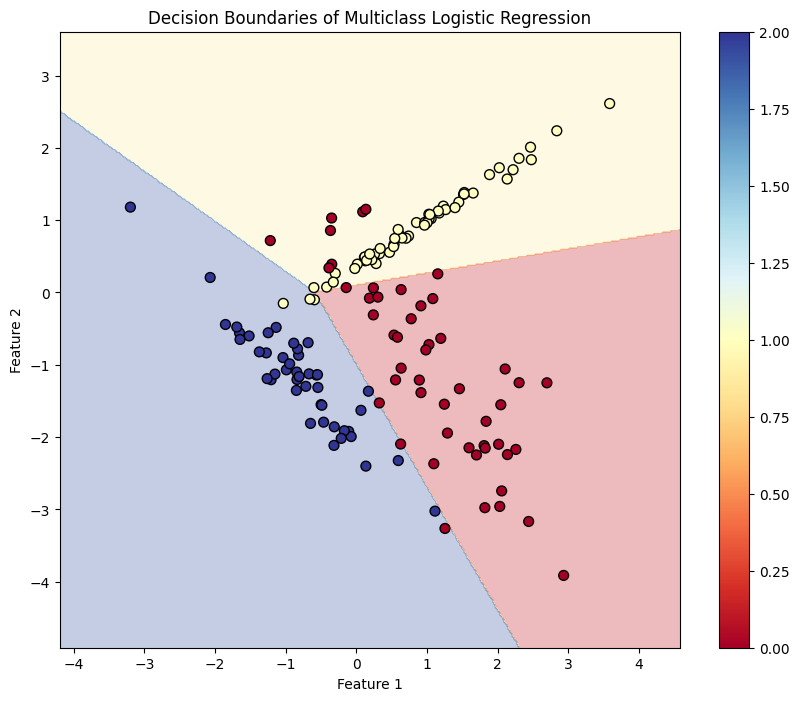

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Генерация синтетических данных для 3 классов
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_classes=3,
    n_clusters_per_class=1,
    n_redundant=0,
    random_state=42
)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Обучение модели
model = MulticlassLogisticRegression(
    n_classes=3,
    learning_rate=0.1,
    n_iterations=1000
)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Визуализация разделяющих границ
def plot_decision_boundary(X, y, model):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu',
                         edgecolor='black', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundaries of Multiclass Logistic Regression')
    plt.colorbar(scatter)
    plt.show()

plot_decision_boundary(X_test, y_test, model)